## **`Data Preparation`**

In [1]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, recall_score, accuracy_score, confusion_matrix, f1_score, matthews_corrcoef
from sklearn.ensemble import RandomForestClassifier


In [2]:
# Load the dataset
chronic_kidney_disease = 'chronic_kidney_disease.csv'

# To display all the columns
pd.options.display.max_columns = None

# To display all the rows
pd.options.display.max_rows = None

# To map Empty Strings or numpy.inf as Na Values
pd.options.mode.use_inf_as_na = True

pd.options.display.expand_frame_repr =  False

%matplotlib inline

# Set Style
sns.set(style = "whitegrid")

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')


chronic_kidney_disease_df = pd.read_csv(chronic_kidney_disease)

C:\Users\zyrat\AppData\Local\Temp\ipykernel_31196\1555632518.py:11: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  pd.options.mode.use_inf_as_na = True


In [3]:
chronic_kidney_disease_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 491 entries, 0 to 490
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Sex                  491 non-null    int64  
 1   AgeBaseline          491 non-null    int64  
 2   HistoryDiabetes      491 non-null    int64  
 3   HistoryCHD           491 non-null    int64  
 4   HistoryVascular      491 non-null    int64  
 5   HistorySmoking       491 non-null    int64  
 6   HistoryHTN           491 non-null    int64  
 7   HistoryDLD           491 non-null    int64  
 8   HistoryObesity       491 non-null    int64  
 9   DLDmeds              491 non-null    int64  
 10  DMmeds               491 non-null    int64  
 11  HTNmeds              491 non-null    int64  
 12  ACEIARB              491 non-null    int64  
 13  CholesterolBaseline  491 non-null    float64
 14  CreatinineBaseline   491 non-null    float64
 15  eGFRBaseline         491 non-null    flo

> The dataframe has total of 491 entries with 22 columns, with no missing values.

In [4]:
chronic_kidney_disease_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Sex,491.0,0.509165,0.500426,0.00,0.0,1.0,1.00,1.0
AgeBaseline,491.0,53.203666,13.821282,23.00,44.0,54.0,64.00,89.0
HistoryDiabetes,491.0,0.437882,0.496632,0.00,0.0,0.0,1.00,1.0
HistoryCHD,491.0,0.091650,0.288825,0.00,0.0,0.0,0.00,1.0
HistoryVascular,491.0,0.059063,0.235983,0.00,0.0,0.0,0.00,1.0
HistorySmoking,491.0,0.152749,0.360113,0.00,0.0,0.0,0.00,1.0
HistoryHTN,491.0,0.682281,0.466064,0.00,0.0,1.0,1.00,1.0
HistoryDLD,491.0,0.645621,0.478812,0.00,0.0,1.0,1.00,1.0
HistoryObesity,491.0,0.505092,0.500484,0.00,0.0,1.0,1.00,1.0
DLDmeds,491.0,0.551935,0.497803,0.00,0.0,1.0,1.00,1.0


In [5]:
chronic_kidney_disease_df.head()

,Sex,AgeBaseline,HistoryDiabetes,HistoryCHD,HistoryVascular,HistorySmoking,HistoryHTN,HistoryDLD,HistoryObesity,DLDmeds,DMmeds,HTNmeds,ACEIARB,CholesterolBaseline,CreatinineBaseline,eGFRBaseline,sBPBaseline,dBPBaseline,BMIBaseline,TimeToEventMonths,EventCKD35,TIME_YEAR
0,0,64,0,0,0,0,1,1,1,1,0,1,0,4.8,59.0,93.3,144,87,40,98,0,8
1,0,52,0,0,0,0,1,1,1,0,0,1,0,6.4,52.0,105.8,148,91,45,106,0,9
2,0,56,0,0,0,0,1,1,1,1,0,1,0,6.4,57.0,99.8,149,86,41,88,0,7
3,0,58,0,0,0,0,0,1,1,1,0,0,0,5.1,65.0,90.3,116,68,32,103,0,9
4,0,63,1,0,0,0,1,1,1,1,1,1,1,5.0,70.0,79.7,132,63,31,105,0,9


#### **`Observation of initial data`**
1. All of the data seems to have been imported. 
2. Data types:  
3. There seems to be no NULL values.
4. There seems to be no duplicated values.


In [6]:
# List of categorical features
chronic_kidney_disease_df.columns = chronic_kidney_disease_df.columns.str.strip()
categorical_features = ['Sex', 'HistoryCHD', 'HistoryVascular', 'HistorySmoking', 'HistoryHTN', 'HistoryDLD', 'HistoryObesity', 
                         'DLDmeds', 'DMmeds', 'HTNmeds', 'ACEIARB']
print([f"'{col}'" for col in chronic_kidney_disease_df.columns])

# Convert to category type
for feature in categorical_features:
   chronic_kidney_disease_df[feature] = chronic_kidney_disease_df[feature].astype('category')


["'Sex'", "'AgeBaseline'", "'HistoryDiabetes'", "'HistoryCHD'", "'HistoryVascular'", "'HistorySmoking'", "'HistoryHTN'", "'HistoryDLD'", "'HistoryObesity'", "'DLDmeds'", "'DMmeds'", "'HTNmeds'", "'ACEIARB'", "'CholesterolBaseline'", "'CreatinineBaseline'", "'eGFRBaseline'", "'sBPBaseline'", "'dBPBaseline'", "'BMIBaseline'", "'TimeToEventMonths'", "'EventCKD35'", "'TIME_YEAR'"]


### **`Data Exploration`**
Five columns or column pairings of the training data set will be visualized and explored. The methodology and the observation will be provided after each visualization.

In [7]:
# Utility Function for labelling
def label_plot(title, xlabel, ylabel):
    """"
    Customize the plot with the title, x and y labels.
    :Params:
        title (str): Title of plot
        xlabel (str): X axis Label
        ylabel(str) : Y axis label
    """
    plt.title(title, fontsize=16)
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.grid()
    plt.show()

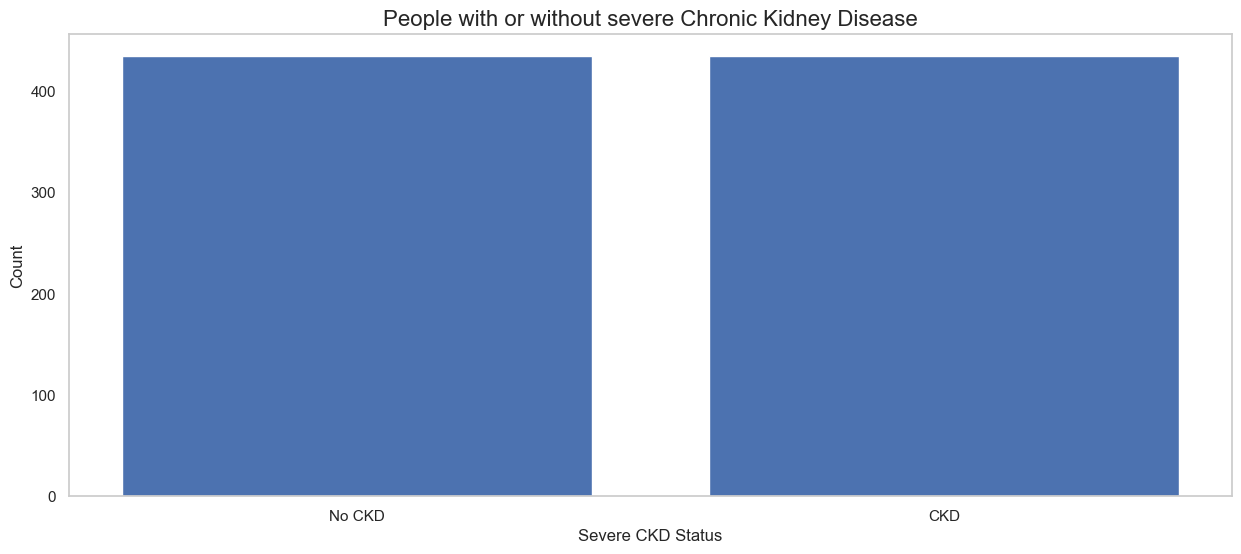

In [8]:
from sklearn.model_selection import train_test_split

X = chronic_kidney_disease_df.drop("EventCKD35", axis=1)
y = chronic_kidney_disease_df["EventCKD35"]
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Count after SMOTE
ckd_counts_resampled = y_resampled.value_counts()
ckd_counts_resampled.index = ['No CKD' if i == 0 else 'CKD' for i in ckd_counts_resampled.index]

# Plot
plt.figure(figsize=(15, 6))
plt.bar(ckd_counts_resampled.index, ckd_counts_resampled.values)
label_plot("People with or without severe Chronic Kidney Disease", "Severe CKD Status", "Count")
plt.show()


There seems to be a huge data imbalance, with significantly more people without CKD in this dataset. This will be addressed with the SMOTE technique for oversampling.

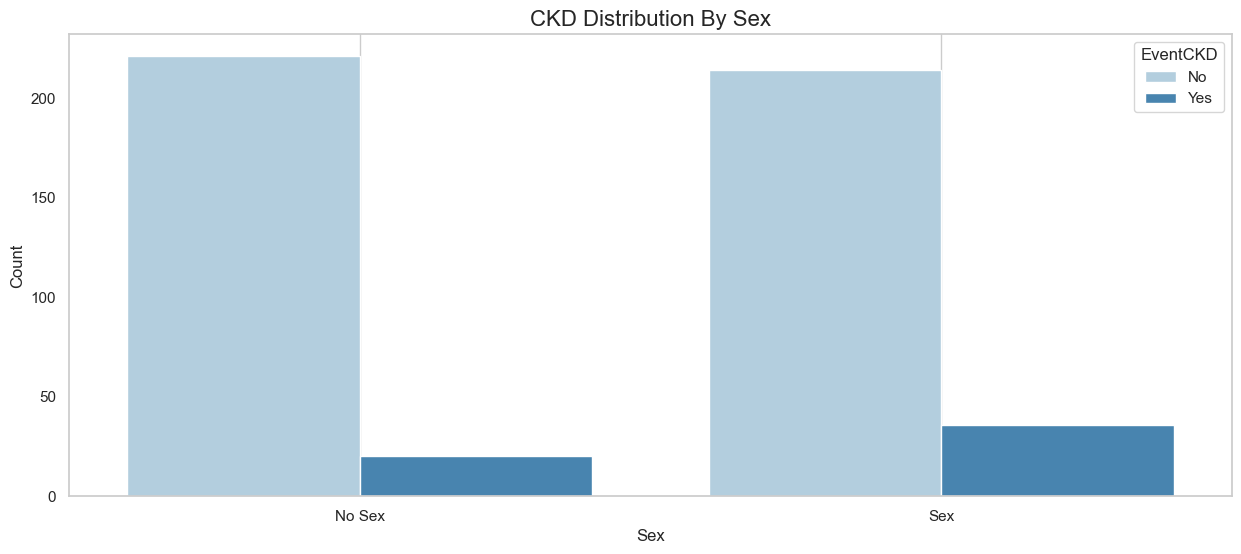

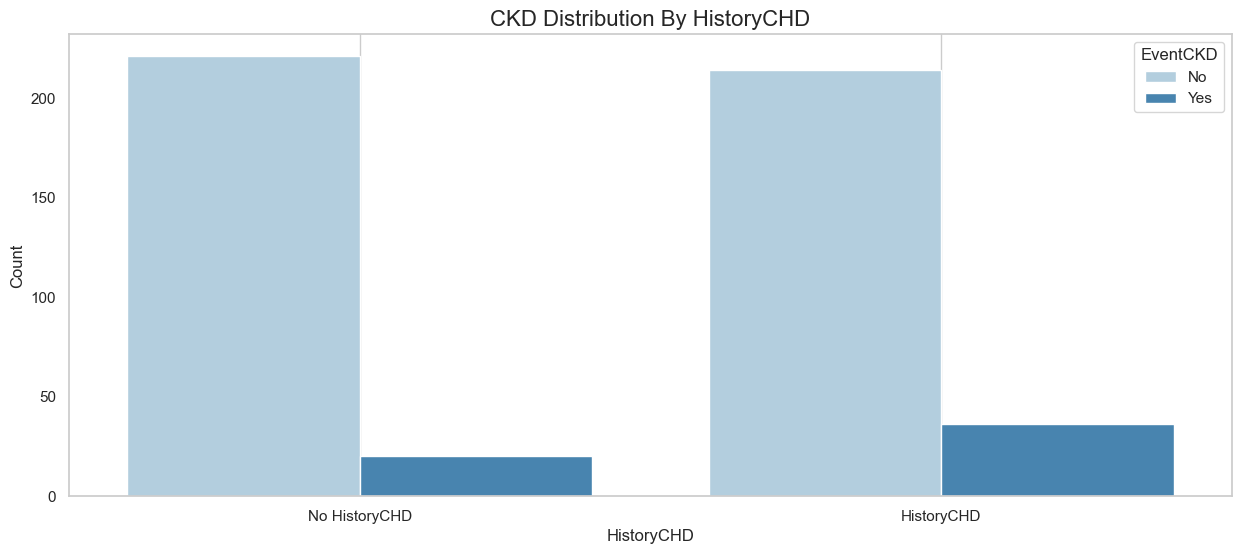

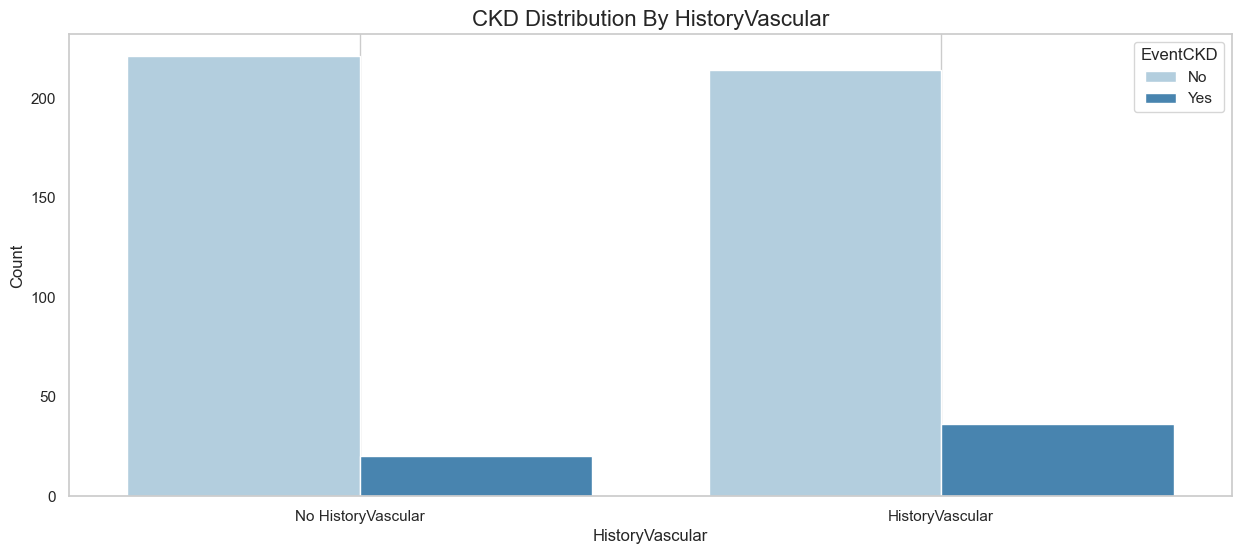

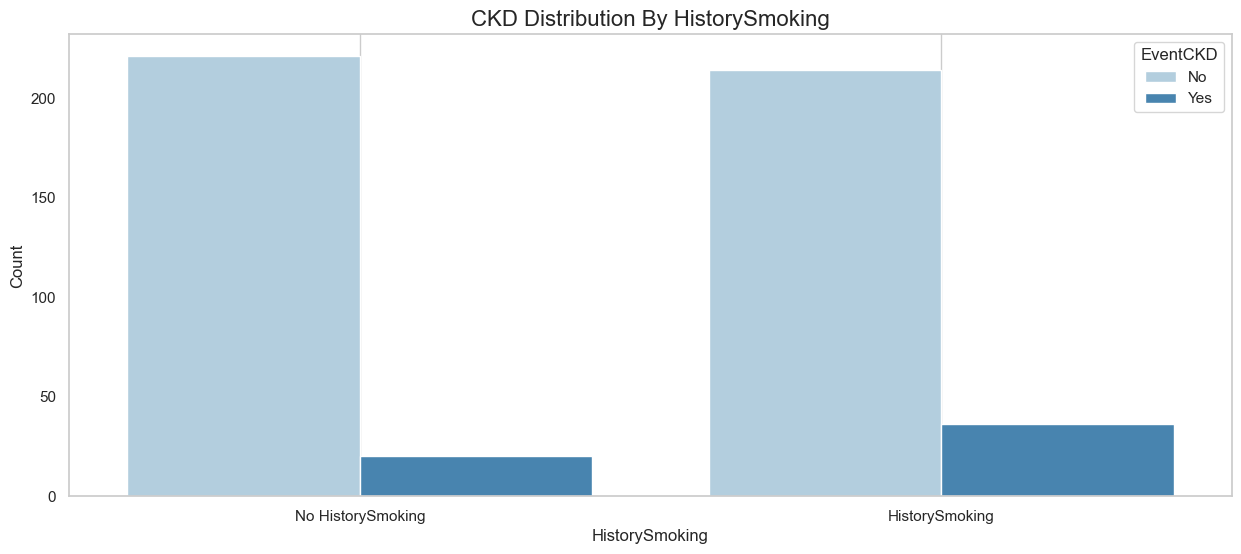

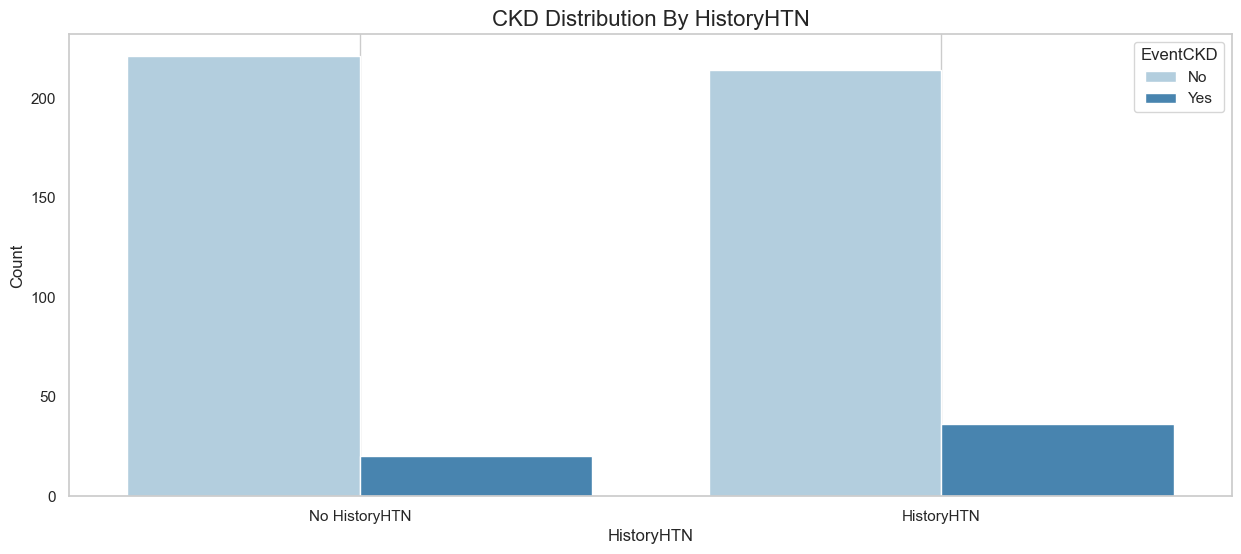

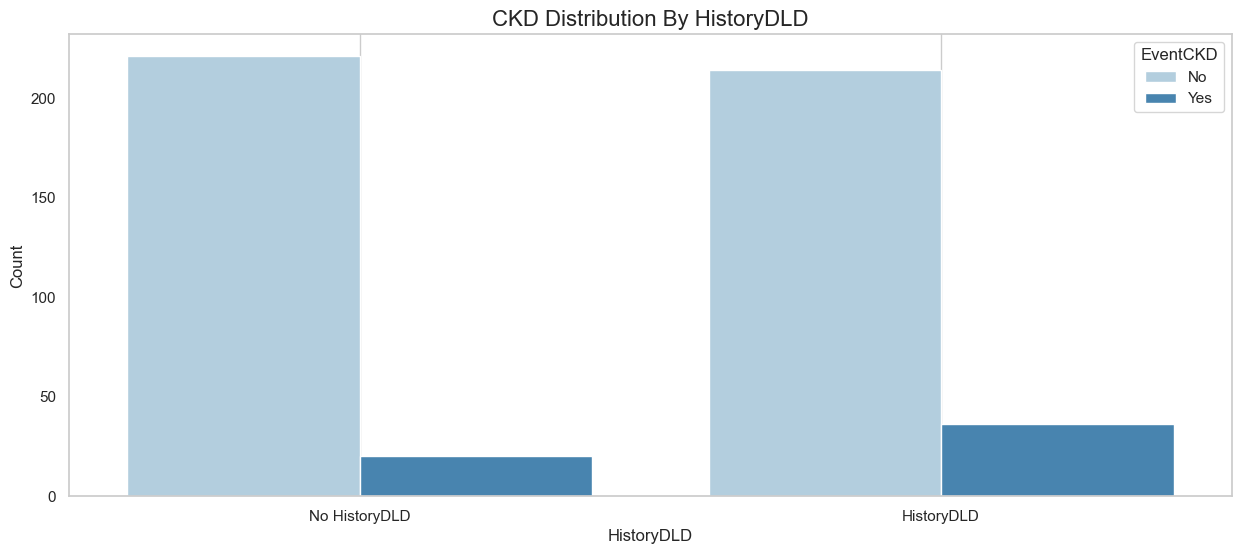

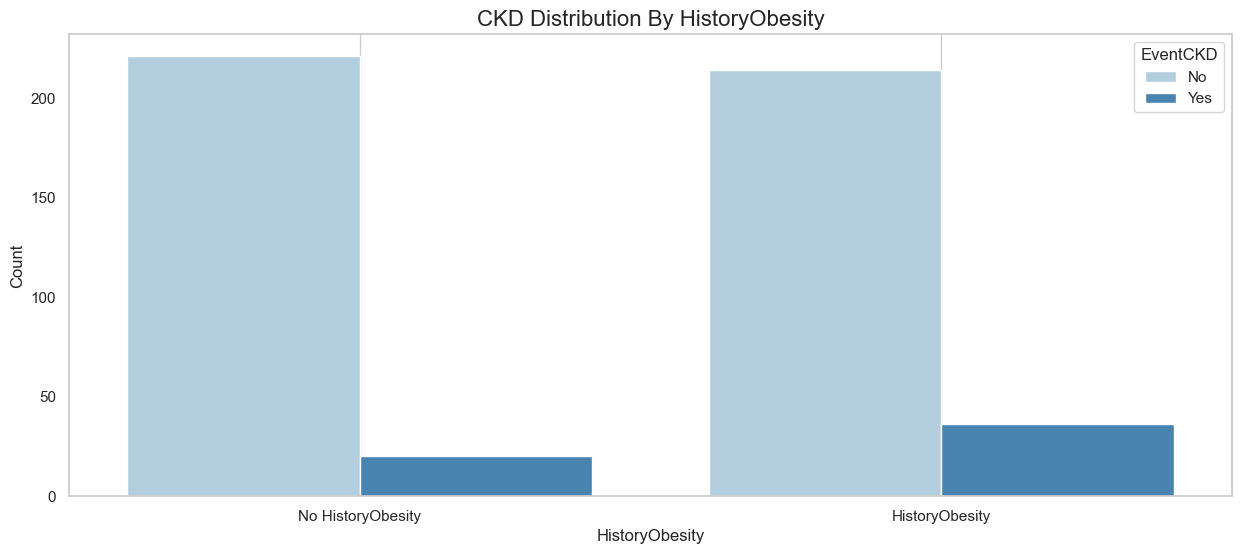

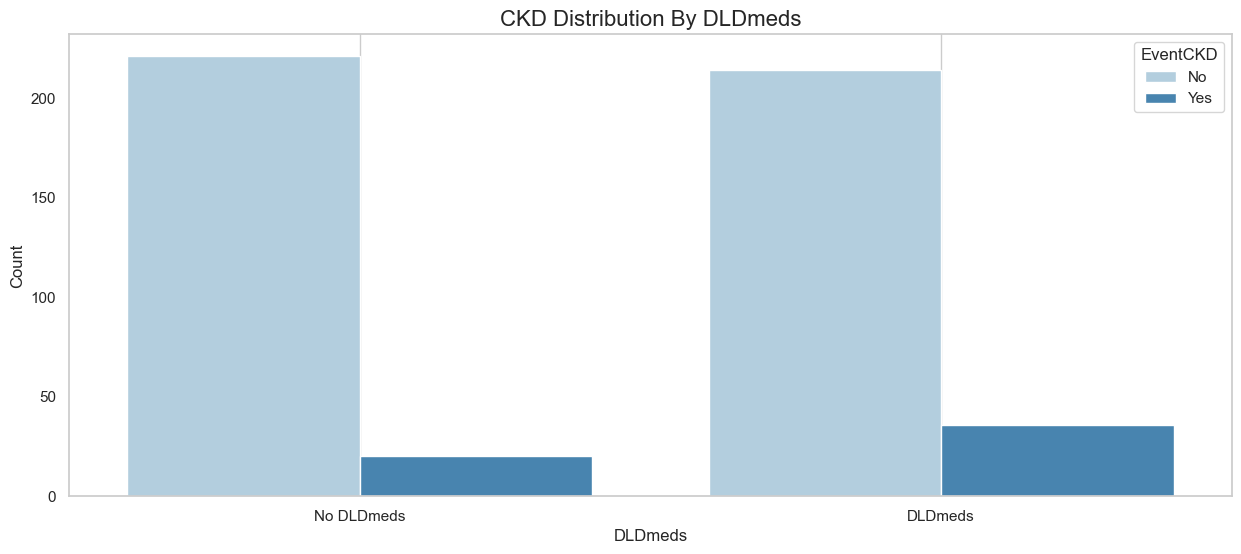

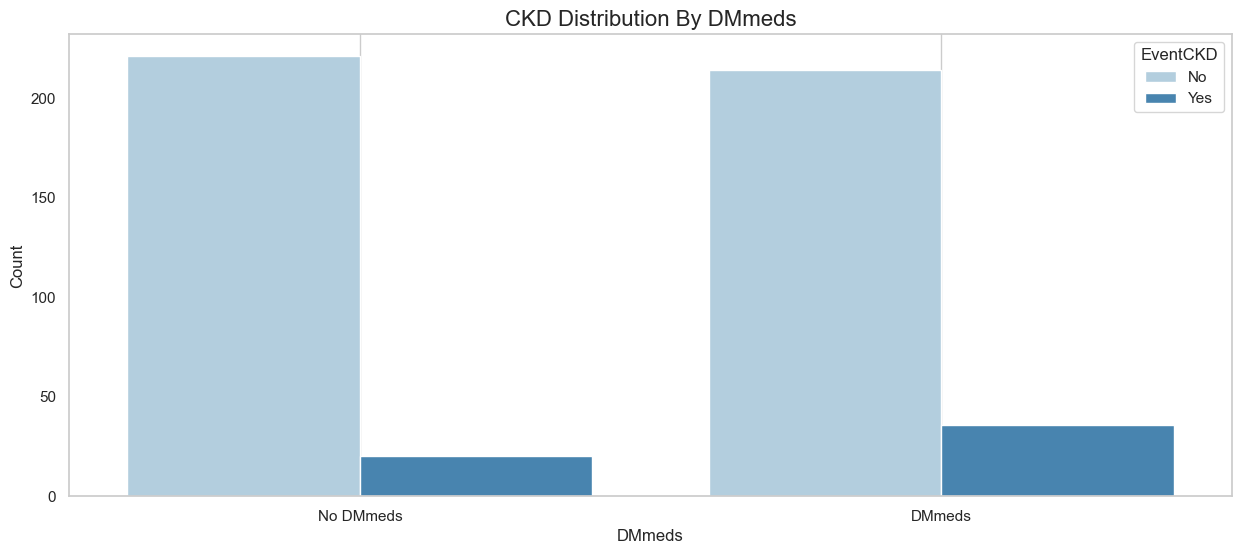

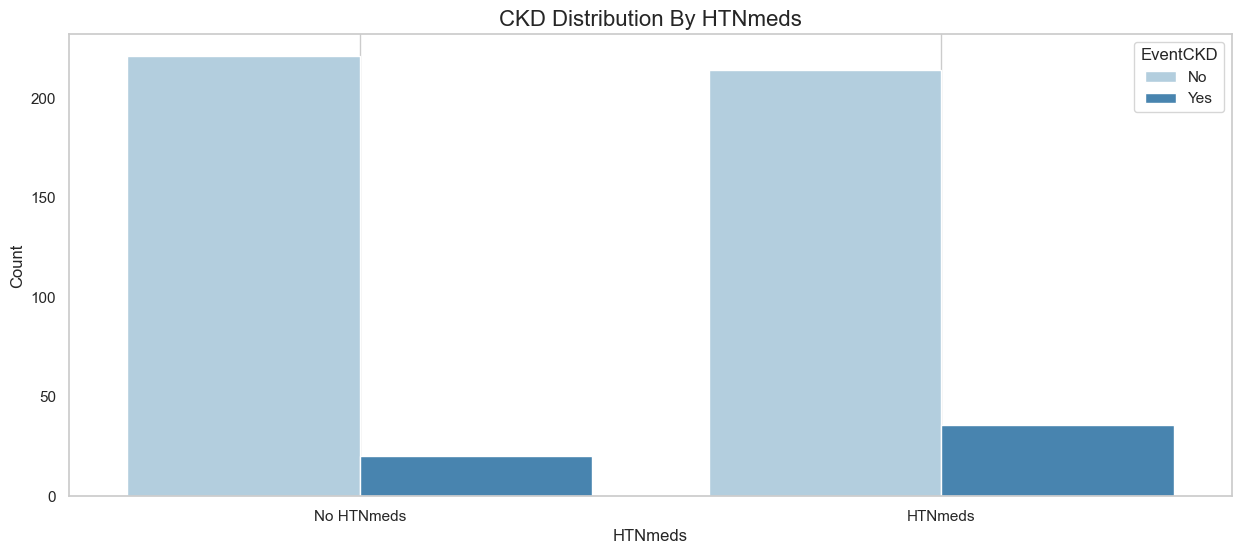

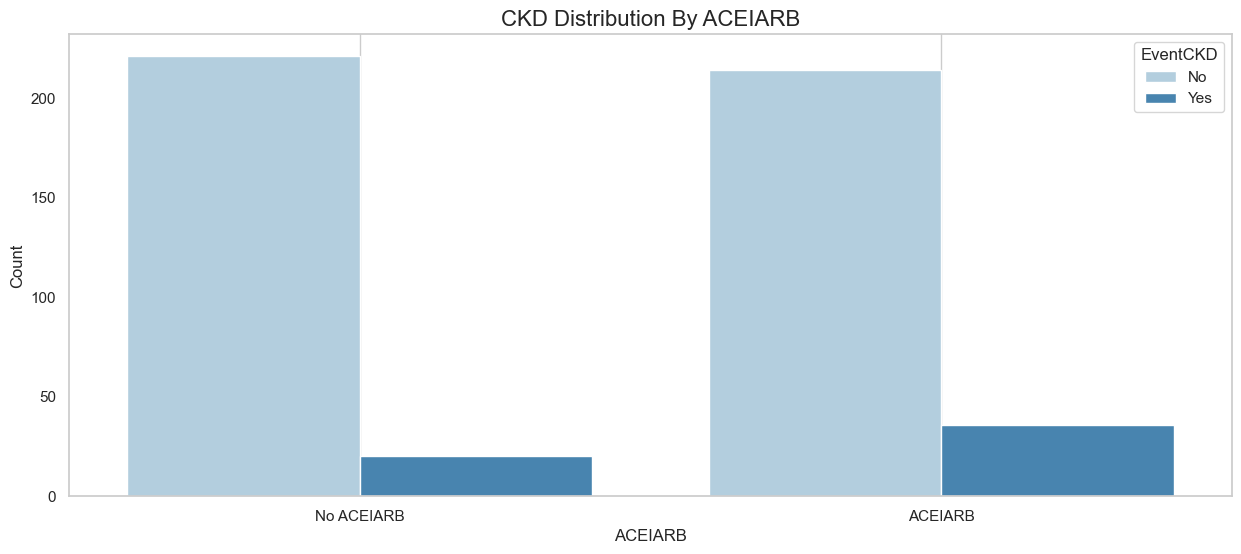

In [9]:
# CKD Distribution by Sex
for feature in categorical_features:
    plt.figure(figsize=(15, 6))
    sns.countplot(data=chronic_kidney_disease_df, x='Sex', hue='EventCKD35', palette='Blues')
    plt.legend(title='EventCKD', labels=['No', 'Yes'])
    plt.xticks([0, 1],[f"No {feature}", f"{feature}"])
    label_plot(f"CKD Distribution By {feature}", f"{feature}", "Count")

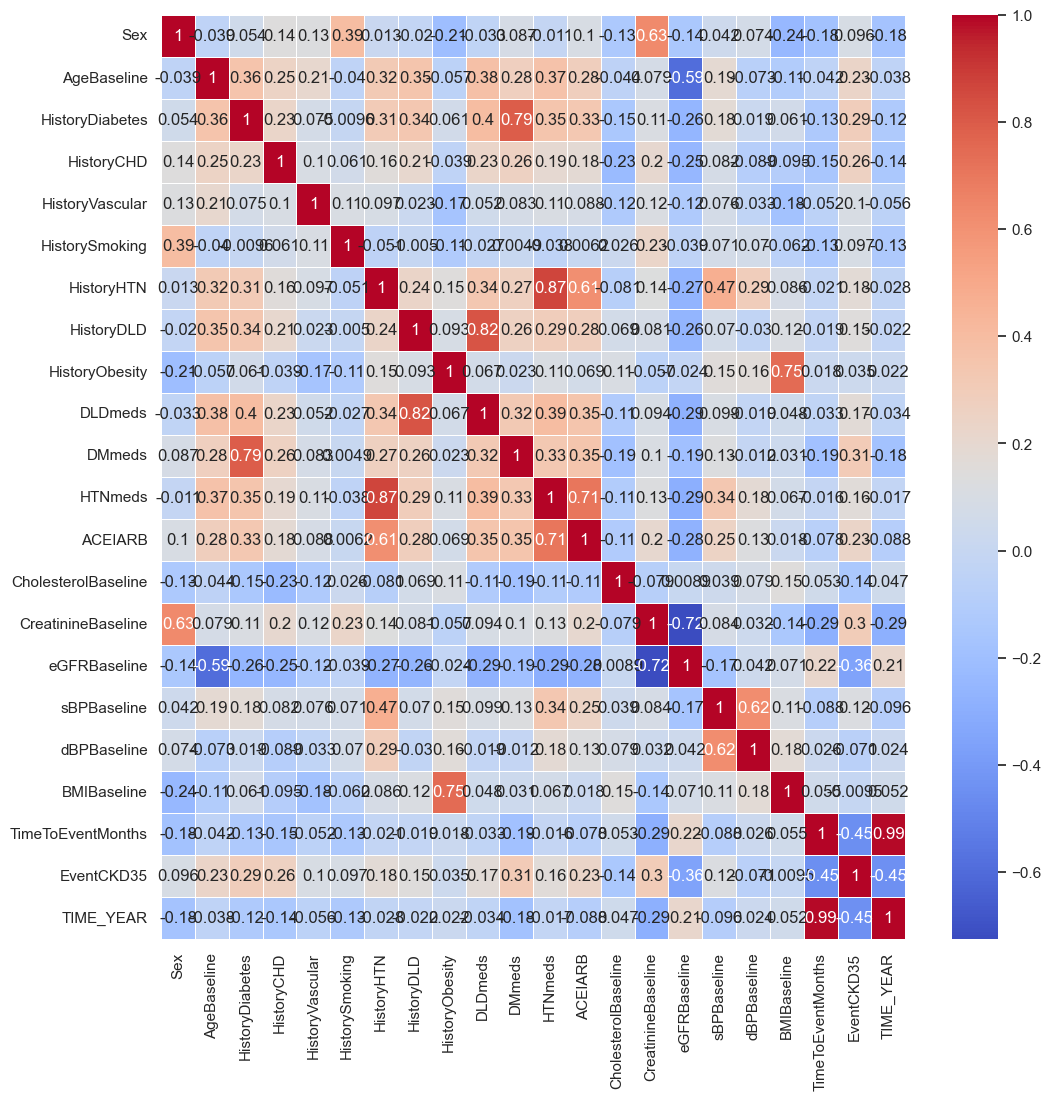

AgeBaseline           0.234616
HistoryDiabetes       0.290294
HistoryCHD            0.263532
DMmeds                0.308959
ACEIARB               0.232300
CreatinineBaseline    0.299953
eGFRBaseline         -0.359031
TimeToEventMonths    -0.449169
EventCKD35            1.000000
TIME_YEAR            -0.447710
Name: EventCKD35, dtype: float64

In [10]:
# Feature engineering
# Correlation analysis
fig, ax = plt.subplots(figsize = (12,12))
correlation_map = chronic_kidney_disease_df.corr()
sns.heatmap(correlation_map, annot =True, linewidths = 0.5, cmap="coolwarm")
plt.show()

# Identifying features with strong correlation to the target
correlation_map[abs(correlation_map['EventCKD35']) > 0.2]['EventCKD35']

#### **`Observation of the correlation matrix`** 
--------------
It seems that the time_year and time to event months have the highest negative correlation with the EventCKD35. The DMMeds has the highest positive correlation with EventCKD35. This is followed closely by History of Diabetes and Creatinine Baseline Levls. CHD, Age, ACEIARB and eGFRBaseline also seem to be closely correlated with CKD Risk. 

In [11]:
# Handle missing values
chronic_kidney_disease_df.ffill(inplace=True)

# Ensure there are no NaN values in the target variable
chronic_kidney_disease_df = chronic_kidney_disease_df.dropna(subset=['EventCKD35'])

# Split the data
X = chronic_kidney_disease_df.drop('EventCKD35', axis=1)
y = chronic_kidney_disease_df['EventCKD35']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier()
model.fit(X_train, y_train)

feature_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)
print(feature_importances)


                Feature  Importance
19    TimeToEventMonths    0.149227
15         eGFRBaseline    0.135896
20            TIME_YEAR    0.120704
1           AgeBaseline    0.082735
14   CreatinineBaseline    0.076074
17          dBPBaseline    0.063388
16          sBPBaseline    0.061761
13  CholesterolBaseline    0.060188
18          BMIBaseline    0.057603
2       HistoryDiabetes    0.037157
10               DMmeds    0.025332
3            HistoryCHD    0.022665
12              ACEIARB    0.020546
4       HistoryVascular    0.014470
5        HistorySmoking    0.014221
9               DLDmeds    0.012375
11              HTNmeds    0.010604
0                   Sex    0.009832
6            HistoryHTN    0.008801
7            HistoryDLD    0.008585
8        HistoryObesity    0.007837


In [12]:
# Splitting the data into features (X) and target (y)
X = chronic_kidney_disease_df.drop(columns=['EventCKD35'])  # Drop the target column
y = chronic_kidney_disease_df['EventCKD35']

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Training the model with all features
model_all_features = RandomForestClassifier(random_state=42)
model_all_features.fit(X_train, y_train)

# Making predictions
y_pred_all = model_all_features.predict(X_test)

# Evaluating performance
print("Performance with All Features:")
print(classification_report(y_test, y_pred_all))
print("Accuracy:", accuracy_score(y_test, y_pred_all))


# Using top features
top_features = ['TimeToEventMonths', 'eGFRBaseline', 'TIME_YEAR', 'AgeBaseline', 
                'CreatinineBaseline', 'dBPBaseline', 'sBPBaseline', 
                'CholesterolBaseline', 'BMIBaseline', 'DMmeds', 'HistoryDiabetes']
X_top = chronic_kidney_disease_df[top_features]

# Train-test split
X_train_top, X_test_top, y_train_top, y_test_top = train_test_split(X_top, y, test_size=0.2, random_state=42)

# Train the model
model_top_features = RandomForestClassifier(random_state=42)
model_top_features.fit(X_train_top, y_train_top)

# Evaluate the model
y_pred_top = model_top_features.predict(X_test_top)
print("Performance with Top Features:")
print(classification_report(y_test_top, y_pred_top))
print("Accuracy:", accuracy_score(y_test_top, y_pred_top))



# Create the directory if it doesn't exist
os.makedirs('model', exist_ok=True)

# Save the model
with open('model/model.pkl', 'wb') as f:
    pickle.dump(model, f)

print("Model training completed and saved to 'model/model.pkl'")

Performance with All Features:
              precision    recall  f1-score   support

           0       0.92      0.99      0.96        87
           1       0.83      0.42      0.56        12

    accuracy                           0.92        99
   macro avg       0.88      0.70      0.76        99
weighted avg       0.91      0.92      0.91        99

Accuracy: 0.9191919191919192
Performance with Top Features:
              precision    recall  f1-score   support

           0       0.93      0.98      0.96        87
           1       0.75      0.50      0.60        12

    accuracy                           0.92        99
   macro avg       0.84      0.74      0.78        99
weighted avg       0.91      0.92      0.91        99

Accuracy: 0.9191919191919192
Model training completed and saved to 'model/model.pkl'


In [13]:

# Train model
# model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
# model_top_features.fit(X_train_top, y_train_top)

# Save the model
# with open('model/model.pkl', 'wb') as f:
    # pickle.dump(model, f)

# print("Model training completed and saved to 'model/model.pkl'")

# Evaluate the model
# y_pred_top = model_top_features.predict(X_test_top)
# print("Performance with Top Features:")
# print(classification_report(y_test_top, y_pred_top))
# print("Accuracy:", accuracy_score(y_test_top, y_pred_top))